# **Linear Discriminant Analysis — Rheumatic & Autoimmune Disease Dataset**

### **Group Members:**
1. Aurelia Safa Madrim (24/545878/TK/60781)
2. Ursula Maurentti Amarely (24/533008/TK/59050)

This notebook implements **Linear Discriminant Analysis (LDA)** for classification of rheumatic and autoimmune diseases.


### **How Linear Discriminant Analysis Works**

Linear Discriminant Analysis is a supervised learning method used for both classification and dimensionality reduction.

LDA works by:

- Using labeled data (Disease), where each data point belongs to a known class.
- Computing class statistics:
  - Mean vector for each class
  - Within-class scatter (variation inside each disease)
  - Between-class scatter (distance between diseases)
- Finding optimal projection:
LDA finds directions (linear combinations of features) that
  - maximize separation between classes while
  - minimizing variation within each class.
- Projecting data:
The dataset is transformed into a lower-dimensional space where classes become more separable.
- Classification:
New data points are assigned to the closest class based on the learned boundaries.

### **Why Supervised for Medical Data?**
Unlike clustering, LDA uses ground-truth labels (Disease) during training.
This is important because:
- Medical datasets already contain verified diagnoses
- The goal is accurate prediction, not just grouping
- LDA maximizes class separability, making it suitable for diagnosis tasks

###  **What we are going to do:**
- Use dataset with ground-truth labels (Disease)
- Train an LDA model using labeled data
- Reduce dimensionality (if needed for visualization)
- Predict disease labels for each data point
- Evaluate classification accuracy

## **CODE PIPELINES:**


---


1.   PHASE 1: Setup and Data Mounting
* Imports
* Mount Google Drive & load Excel file
* Peek at the data (shape, columns, missing values)

2.   PHASE 2: Exploratory Data Analysis (EDA)
* Missing values bar chart
* Disease label distribution

3. Phase 3: Preprocessing
* Fill missing values
* Encode categorical columns (Gender, HLA-B27, etc.) into numbers
* Shuffle & separate features (X) from label (y)
* Min-Max normalisation

4. Phase 4: Linear Discriminant Analysis (LDA)
* Compute class means
* Compute within-class scatter matrix (Sw)
* Compute between-class scatter matrix (Sb)
* Solve eigenvalue problem to find discriminant directions
* Project data into lower-dimensional LDA space

5. Phase 5: Classification (Nearest Centroid)
* Compute centroids for each disease in LDA space
* Assign each patient to the nearest disease centroid
* Generate predicted disease labels

6. Phase 6 — Evaluate Accuracy
* Compare predicted disease vs ground-truth
* Compute overall accuracy
* Crosstab heatmap (predicted vs actual disease)

7. Phase 7: Visualisation
* LDA projection (2D scatter: predicted vs actual labels)
* Class separation plots for each LDA component
* Feature importance per LDA component



#**PHASE 1: SETUP AND DATA MOUNTING**


---



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# a. Mount Drive and Load Data
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = "/content/drive/MyDrive/Rheumatic and Autoimmune Disease Dataset.xlsx"
df = pd.read_excel(FILE_PATH)

# b. Data Preview
print("Shape   :", df.shape)
print("Columns :", df.columns.tolist())
print()
print("Missing values per column:")
print(df.isnull().sum())
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape   : (12085, 15)
Columns : ['Age', 'Gender', 'ESR', 'CRP', 'RF', 'Anti-CCP', 'HLA-B27', 'ANA', 'Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm', 'C3', 'C4', 'Disease']

Missing values per column:
Age              0
Gender           0
ESR           1088
CRP           2417
RF            1329
Anti-CCP      3263
HLA-B27       1934
ANA           3746
Anti-Ro       2900
Anti-La       3021
Anti-dsDNA    4713
Anti-Sm       5197
C3            1692
C4            2054
Disease          0
dtype: int64


,Age,Gender,ESR,CRP,RF,Anti-CCP,HLA-B27,ANA,Anti-Ro,Anti-La,Anti-dsDNA,Anti-Sm,C3,C4,Disease
0,70,Male,39.0,18.6,34.2,29.9,Positive,Negative,Positive,Negative,Positive,Positive,NaN,27.0,Rheumatoid Arthritis
1,39,Female,26.0,21.7,35.5,28.9,Negative,NaN,Positive,NaN,Positive,NaN,100.0,66.0,Rheumatoid Arthritis
2,36,Female,41.0,15.6,21.3,21.3,Negative,Negative,NaN,Positive,Negative,NaN,158.0,12.0,Rheumatoid Arthritis
3,35,Male,43.0,23.4,26.0,39.0,NaN,NaN,Positive,Positive,NaN,NaN,119.0,41.0,Rheumatoid Arthritis
4,37,Female,30.0,NaN,38.1,30.8,Positive,Negative,Positive,Negative,Positive,Negative,144.0,49.0,Rheumatoid Arthritis


#**PHASE 2: EXPLORATORY DATA ANALYSIS**
---



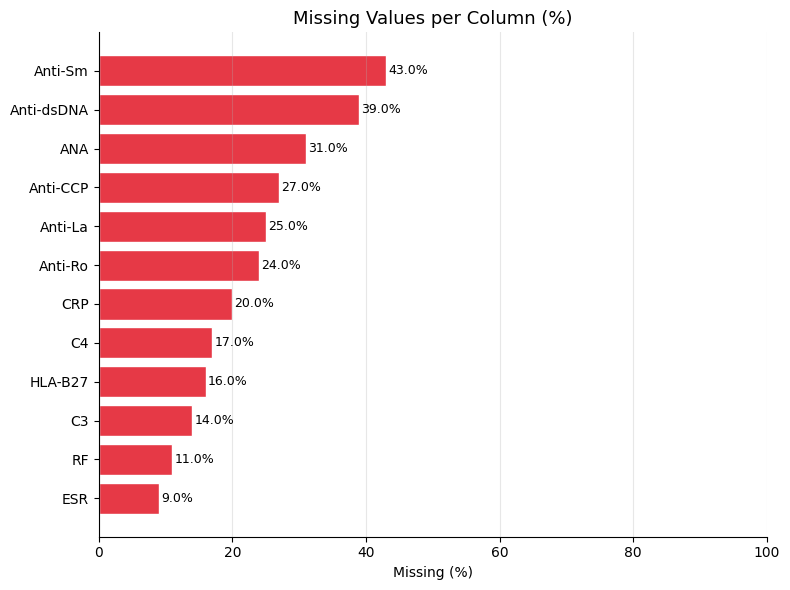

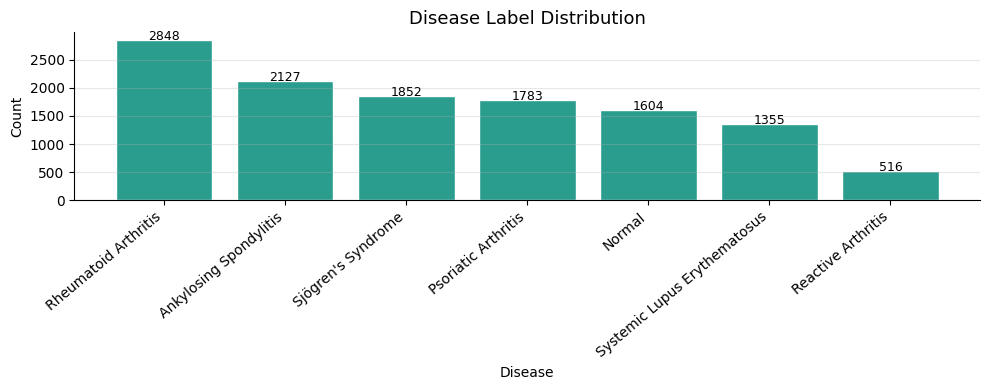

In [9]:
# a. Missing Values Bar Chart
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(3, len(missing_pct) * 0.5)))
ax.barh(missing_pct.index, missing_pct.values, color='#E63946', edgecolor='white')

for i, (col, val) in enumerate(missing_pct.items()):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)

ax.set_title('Missing Values per Column (%)', fontsize=13)
ax.set_xlabel('Missing (%)'), ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# b. Disease Distribution
disease_counts = df['Disease'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(disease_counts.index, disease_counts.values, color='#2A9D8F', edgecolor='white')

for i, val in enumerate(disease_counts.values):
    ax.text(i, val + 0.5, str(val), ha='center', fontsize=9)

ax.set_title('Disease Label Distribution', fontsize=13)
ax.set_xlabel('Disease'), ax.set_ylabel('Count')
plt.xticks(rotation=40, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

#**PHASE 3: PREPROCESSING**
---



In [10]:
# a. Fill Missing Values
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing after imputation:", df.isnull().sum().sum())

# b. Encode Categories Into Numbers
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

binary_cols = ['HLA-B27', 'ANA', 'Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm']
for col in binary_cols:
    df[col] = df[col].map({'Positive': 1, 'Negative': 0})

# c. Shuffling Data and Split
df = df.sample(frac=1, random_state=10).reset_index(drop=True)

X = df.drop('Disease', axis=1).values
y = df['Disease'].values

# Stratified sample
N_SAMPLES  = 10000
classes, counts = np.unique(y, return_counts=True)
proportions     = counts / len(y)

sampled_idx = []
rng         = np.random.default_rng(42)

for cls, prop in zip(classes, proportions):
    cls_idx    = np.where(y == cls)[0]
    n_sample   = int(np.round(prop * N_SAMPLES))
    n_sample   = min(n_sample, len(cls_idx))
    sampled_idx.extend(rng.choice(cls_idx, size=n_sample, replace=False))

sampled_idx = np.array(sampled_idx)
rng.shuffle(sampled_idx)

X, y = X[sampled_idx], y[sampled_idx]

print(f"Using {len(X)} stratified samples out of {len(df)} total")
print("\nClass distribution after sampling:")
for cls, count in zip(*np.unique(y, return_counts=True)):
    print(f"  {cls:<30} {count:>5}  ({count/len(y)*100:.1f}%)")

# d. Min Max Normalization
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X = (X - X_min) / (X_max - X_min)

print("X shape :", X.shape)
print("Value range - min:", X.min().round(4), " max:", X.max().round(4))

Missing after imputation: 0
Using 9999 stratified samples out of 12085 total

Class distribution after sampling:
  Ankylosing Spondylitis          1760  (17.6%)
  Normal                          1327  (13.3%)
  Psoriatic Arthritis             1475  (14.8%)
  Reactive Arthritis               427  (4.3%)
  Rheumatoid Arthritis            2357  (23.6%)
  Sjögren's Syndrome              1532  (15.3%)
  Systemic Lupus Erythematosus    1121  (11.2%)
X shape : (9999, 14)
Value range - min: 0.0  max: 1.0


#**PHASE 4: LINEAR DISCRIMINANT ANALYSIS**
---



In [11]:
# a.  Distance Function
def euclidean(a, b):
    diff = a - b
    return np.sqrt(np.dot(diff, diff))


# b. Compute Class Means
def compute_means(X, y):
    classes      = np.unique(y)
    overall_mean = X.mean(axis=0)
    class_means  = {}

    for cls in classes:
        class_means[cls] = X[y == cls].mean(axis=0)
        print(f"  '{cls}' : {(y == cls).sum()} samples")

    return overall_mean, class_means

print("Computing...")
overall_mean, class_means = compute_means(X, y)

# c. Within Class Scatter Matrix
def compute_Sw(X, y, class_means):
    n_features = X.shape[1]
    Sw         = np.zeros((n_features, n_features))

    for cls, mean in class_means.items():
        mask    = y == cls
        X_cls   = X[mask] - mean
        Sw     += X_cls.T @ X_cls

    return Sw

print("Computing within-class scatter matrix (Sw)...")
Sw = compute_Sw(X, y, class_means)
print(f"Sw shape : {Sw.shape}")


# d. Between Class Scatter Matrix
def compute_Sb(X, y, overall_mean, class_means):
    n_features = X.shape[1]
    Sb         = np.zeros((n_features, n_features))

    for cls, mean in class_means.items():
        n    = (y == cls).sum()
        diff = (mean - overall_mean).reshape(-1, 1)
        Sb  += n * (diff @ diff.T)

    return Sb

print("Computing between-class scatter matrix (Sb)...")
Sb = compute_Sb(X, y, overall_mean, class_means)
print(f"Sb shape : {Sb.shape}")

# e. Eigencomposition
def compute_lda_components(Sw, Sb, n_components):
    Sw_inv      = np.linalg.inv(Sw)
    matrix      = Sw_inv @ Sb

    # eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    # sort by descending
    order       = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[order].real
    eigenvectors = eigenvectors[:, order].real

    # keep top n_components
    components  = eigenvectors[:, :n_components]

    print("Top eigenvalues (discrimination power per component):")
    for i, val in enumerate(eigenvalues[:n_components]):
        pct = val / eigenvalues.sum() * 100
        print(f"  LD{i+1} : {val:.4f}  ({pct:.1f}% of total separation)")

    return components

# max useful components = n_classes - 1
N_COMPONENTS = len(np.unique(y)) - 1
print(f"Computing LDA components (max useful = {N_COMPONENTS})...")
lda_components = compute_lda_components(Sw, Sb, N_COMPONENTS)
print(f"\nProjection matrix shape : {lda_components.shape}")

# f. Project Data Into LDA Components
def lda_transform(X, components):
    return X @ components

print("Projecting data...")
X_lda = lda_transform(X, lda_components)
print(f"Original shape : {X.shape}")
print(f"LDA shape      : {X_lda.shape}")

Computing...
  'Ankylosing Spondylitis' : 1760 samples
  'Normal' : 1327 samples
  'Psoriatic Arthritis' : 1475 samples
  'Reactive Arthritis' : 427 samples
  'Rheumatoid Arthritis' : 2357 samples
  'Sjögren's Syndrome' : 1532 samples
  'Systemic Lupus Erythematosus' : 1121 samples
Computing within-class scatter matrix (Sw)...
Sw shape : (14, 14)
Computing between-class scatter matrix (Sb)...
Sb shape : (14, 14)
Computing LDA components (max useful = 6)...
Top eigenvalues (discrimination power per component):
  LD1 : 6.1976  (75.4% of total separation)
  LD2 : 0.9513  (11.6% of total separation)
  LD3 : 0.7698  (9.4% of total separation)
  LD4 : 0.1740  (2.1% of total separation)
  LD5 : 0.1238  (1.5% of total separation)
  LD6 : 0.0010  (0.0% of total separation)

Projection matrix shape : (14, 6)
Projecting data...
Original shape : (9999, 14)
LDA shape      : (9999, 6)


#**PHASE 5: CLASSIFICATION**
---



In [12]:
# a. Compute Centroids in LDA Space
def compute_centroids(X_lda, y):
    centroids = {}
    for cls in np.unique(y):
        centroids[cls] = X_lda[y == cls].mean(axis=0)
        print(f"  '{cls}' centroid : {centroids[cls].round(3)}")
    return centroids

print("Computing...")
centroids = compute_centroids(X_lda, y)

# b. Predict by Nearest Centroid
def predict(X_lda, centroids):
    classes   = list(centroids.keys())
    y_pred    = []

    for point in X_lda:
        # compute distance from this patient to every disease centroid
        distances = {cls: euclidean(point, centroid)
                     for cls, centroid in centroids.items()}
        # assign the disease whose centroid is closest
        y_pred.append(min(distances, key=distances.get))

    return np.array(y_pred)

print("Predicting disease labels...")
y_pred = predict(X_lda, centroids)
print("Done.")

# c. Check
preview = pd.DataFrame({
    'Predicted' : y_pred,
    'Actual'    : y
})

print(preview.head(15))
print(f"\nUnique predicted diseases : {np.unique(y_pred).tolist()}")

Computing...
  'Ankylosing Spondylitis' centroid : [-0.964  0.342 -0.711  0.086 -1.225  0.565]
  'Normal' centroid : [-0.29   0.097 -0.752 -0.021 -0.883  0.569]
  'Psoriatic Arthritis' centroid : [-1.076  0.117 -0.506 -0.25  -1.132  0.573]
  'Reactive Arthritis' centroid : [-0.764  0.342 -0.755  0.124 -1.162  0.598]
  'Rheumatoid Arthritis' centroid : [-1.015  0.61  -0.824 -0.135 -0.985  0.571]
  'Sjögren's Syndrome' centroid : [-0.279  0.377 -0.935 -0.208 -1.261  0.571]
  'Systemic Lupus Erythematosus' centroid : [-0.223  0.684 -0.348 -0.082 -1.111  0.571]
Predicting disease labels...
Done.
                       Predicted                        Actual
0         Ankylosing Spondylitis        Ankylosing Spondylitis
1         Ankylosing Spondylitis        Ankylosing Spondylitis
2             Reactive Arthritis        Ankylosing Spondylitis
3   Systemic Lupus Erythematosus  Systemic Lupus Erythematosus
4                         Normal                        Normal
5             Sjögren's

#**PHASE 6: EVALUATE ACCURACY**
---



Overall Accuracy : 0.7456  (74.6%)

Per-Disease Accuracy:
Disease                             Correct   Total  Accuracy
--------------------------------------------------------------
  Ankylosing Spondylitis                971    1760     55.2%
  Normal                                949    1327     71.5%
  Psoriatic Arthritis                  1143    1475     77.5%
  Reactive Arthritis                    309     427     72.4%
  Rheumatoid Arthritis                 1620    2357     68.7%
  Sjögren's Syndrome                   1435    1532     93.7%
  Systemic Lupus Erythematosus         1028    1121     91.7%


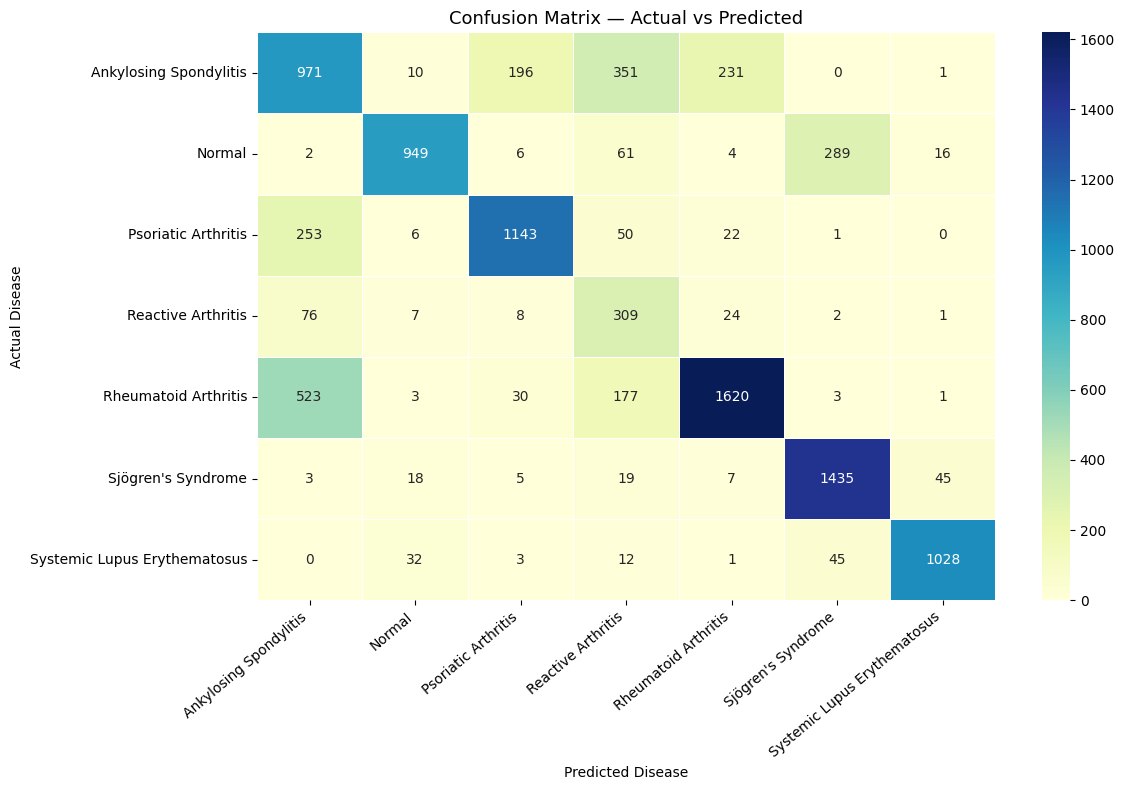


Per-Disease Precision & Recall:
Disease                              Precision     Recall
----------------------------------------------------------
  Ankylosing Spondylitis                53.1%     55.2%
  Normal                                92.6%     71.5%
  Psoriatic Arthritis                   82.2%     77.5%
  Reactive Arthritis                    31.6%     72.4%
  Rheumatoid Arthritis                  84.9%     68.7%
  Sjögren's Syndrome                    80.8%     93.7%
  Systemic Lupus Erythematosus          94.1%     91.7%
METRICS SUMMARY
  Overall Accuracy : 74.56%
  MSE              : 2.5166
  MAE              : 0.7444

Disease                              Precision     Recall         F1
--------------------------------------------------------------------
  Ankylosing Spondylitis                53.1%     55.2%     54.1%
  Normal                                92.6%     71.5%     80.7%
  Psoriatic Arthritis                   82.2%     77.5%     79.8%
  Reactive Arthritis 

In [13]:
# a. Overall Accuracy
accuracy = np.sum(y_pred == y) / len(y)
print(f"Overall Accuracy : {accuracy:.4f}  ({accuracy*100:.1f}%)")

# b. Per Disease Accuracy
print("\nPer-Disease Accuracy:")
print(f"{'Disease':<35} {'Correct':>7} {'Total':>7} {'Accuracy':>9}")
print("-" * 62)
for disease in np.unique(y):
    mask    = y == disease
    correct = np.sum(y_pred[mask] == y[mask])
    total   = mask.sum()
    pct     = correct / total * 100
    print(f"  {disease:<33} {correct:>7} {total:>7} {pct:>8.1f}%")


# c. Heatmap
diseases = np.unique(y)
n        = len(diseases)
cm       = np.zeros((n, n), dtype=int)
d_index  = {d: i for i, d in enumerate(diseases)}

for actual, predicted in zip(y, y_pred):
    cm[d_index[actual]][d_index[predicted]] += 1

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=diseases, yticklabels=diseases,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — Actual vs Predicted', fontsize=13)
ax.set_xlabel('Predicted Disease')
ax.set_ylabel('Actual Disease')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# d. Precision and Recall Per-Disease
print("\nPer-Disease Precision & Recall:")
print(f"{'Disease':<35} {'Precision':>10} {'Recall':>10}")
print("-" * 58)

for i, disease in enumerate(diseases):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp    # predicted as this disease but wrong
    fn = cm[i, :].sum() - tp    # actually this disease but predicted wrong

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"  {disease:<33} {precision:>9.1%} {recall:>9.1%}")

# e. Error Metrics
disease_list  = np.unique(y)
d_to_int      = {d: i for i, d in enumerate(disease_list)}
y_int         = np.array([d_to_int[d] for d in y])
y_pred_int    = np.array([d_to_int[d] for d in y_pred])

# MSE
mse  = np.mean((y_int - y_pred_int) ** 2)

# MAE
mae  = np.mean(np.abs(y_int - y_pred_int))

# F1 per disease (harmonic mean of precision & recall)
print("=" * 62)
print("METRICS SUMMARY")
print("=" * 62)
print(f"  Overall Accuracy : {accuracy*100:.2f}%")
print(f"  MSE              : {mse:.4f}")
print(f"  MAE              : {mae:.4f}")

print(f"\n{'Disease':<35} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 68)

f1_scores = []
for i, disease in enumerate(disease_list):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * (precision * recall) / (precision + recall) \
                if (precision + recall) > 0 else 0.0
    f1_scores.append(f1)

    print(f"  {disease:<33} {precision:>9.1%} {recall:>9.1%} {f1:>9.1%}")

print("-" * 68)
print(f"  {'Macro Average':<33} "
      f"{np.mean([cm[i,i]/(cm[:,i].sum()) for i in range(len(disease_list))]):>9.1%} "
      f"{np.mean([cm[i,i]/(cm[i,:].sum()) for i in range(len(disease_list))]):>9.1%} "
      f"{np.mean(f1_scores):>9.1%}")

Running 5-Fold Cross Validation...
  Total samples : 9999  |  Fold size : 1999

  'Ankylosing Spondylitis' : 1408 samples
  'Normal' : 1072 samples
  'Psoriatic Arthritis' : 1174 samples
  'Reactive Arthritis' : 339 samples
  'Rheumatoid Arthritis' : 1895 samples
  'Sjögren's Syndrome' : 1211 samples
  'Systemic Lupus Erythematosus' : 901 samples
Top eigenvalues (discrimination power per component):
  LD1 : 6.1970  (75.3% of total separation)
  LD2 : 0.9575  (11.6% of total separation)
  LD3 : 0.7756  (9.4% of total separation)
  LD4 : 0.1702  (2.1% of total separation)
  LD5 : 0.1285  (1.6% of total separation)
  LD6 : 0.0010  (0.0% of total separation)
  'Ankylosing Spondylitis' centroid : [ 0.977 -0.376 -0.695  0.066 -1.144  0.606]
  'Normal' centroid : [ 0.3   -0.124 -0.739 -0.028 -0.802  0.61 ]
  'Psoriatic Arthritis' centroid : [ 1.083 -0.147 -0.499 -0.274 -1.036  0.614]
  'Reactive Arthritis' centroid : [ 0.778 -0.365 -0.745  0.115 -1.075  0.641]
  'Rheumatoid Arthritis' centroi

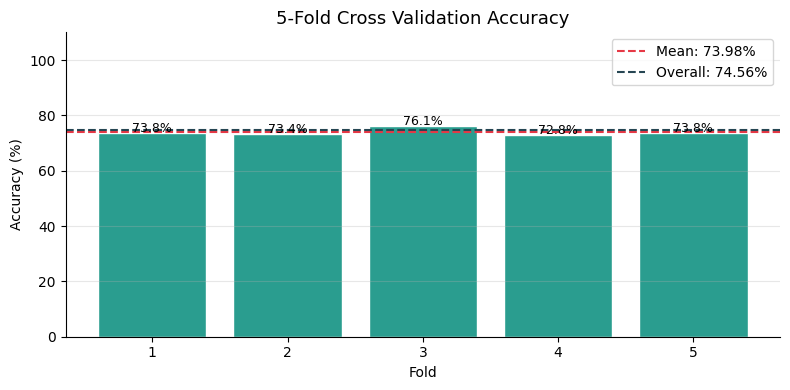

In [14]:
# K - Fold Validation
def kfold_cross_validation(X, y, k=5):
    N          = len(X)
    fold_size  = N // k
    indices    = np.arange(N)
    accuracies = []

    print(f"Running {k}-Fold Cross Validation...")
    print(f"  Total samples : {N}  |  Fold size : {fold_size}")
    print()

    for fold in range(k):
        # split into train / test
        test_start = fold * fold_size
        test_end   = test_start + fold_size if fold < k - 1 else N

        test_idx   = indices[test_start:test_end]
        train_idx  = np.concatenate([indices[:test_start],
                                     indices[test_end:]])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # train LDA on this fold
        fold_overall_mean, fold_class_means = compute_means(X_train, y_train)
        fold_Sw         = compute_Sw(X_train, y_train, fold_class_means)
        fold_Sb         = compute_Sb(X_train, y_train,
                                     fold_overall_mean, fold_class_means)
        fold_components = compute_lda_components(fold_Sw, fold_Sb, N_COMPONENTS)

        # project & predict
        X_train_lda  = lda_transform(X_train, fold_components)
        X_test_lda   = lda_transform(X_test,  fold_components)
        fold_centroids = compute_centroids(X_train_lda, y_train)
        fold_pred    = predict(X_test_lda, fold_centroids)

        # score
        acc = np.sum(fold_pred == y_test) / len(y_test)
        accuracies.append(acc)
        print(f"  Fold {fold+1} — test size: {len(test_idx):>4}  |  "
              f"accuracy: {acc*100:.2f}%")

    mean_acc = np.mean(accuracies)
    std_acc  = np.std(accuracies)

    print()
    print("=" * 45)
    print(f"  K-Fold Mean Accuracy : {mean_acc*100:.2f}%")
    print(f"  K-Fold Std Dev       : {std_acc*100:.2f}%")
    print(f"  Overall Model Acc    : {accuracy*100:.2f}%")
    print("=" * 45)

    # plot fold accuracies
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(1, k+1), [a*100 for a in accuracies],
           color='#2A9D8F', edgecolor='white')
    ax.axhline(mean_acc*100, color='#E63946', linewidth=1.5,
               linestyle='--', label=f'Mean: {mean_acc*100:.2f}%')
    ax.axhline(accuracy*100, color='#264653', linewidth=1.5,
               linestyle='--', label=f'Overall: {accuracy*100:.2f}%')
    for i, acc in enumerate(accuracies):
        ax.text(i+1, acc*100 + 0.3, f'{acc*100:.1f}%',
                ha='center', fontsize=9)
    ax.set_title(f'{k}-Fold Cross Validation Accuracy', fontsize=13)
    ax.set_xlabel('Fold'), ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 110)
    ax.legend(), ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    return accuracies, mean_acc, std_acc


fold_accuracies, kfold_mean, kfold_std = kfold_cross_validation(X, y, k=5)

#**PHASE 7: VISUALISATION**
---



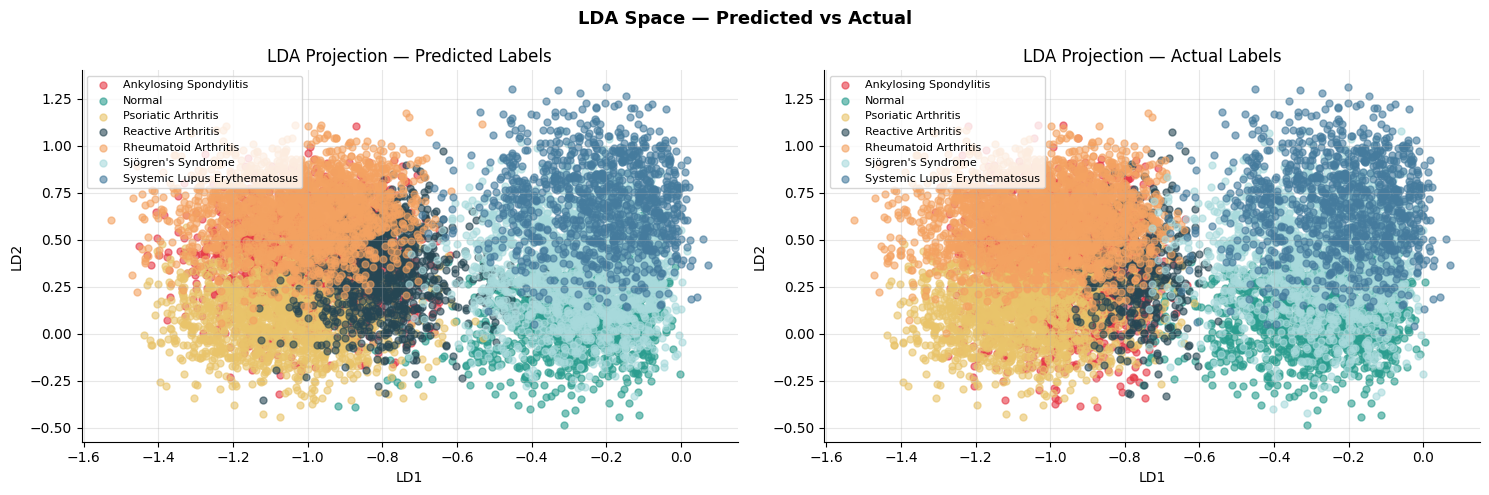

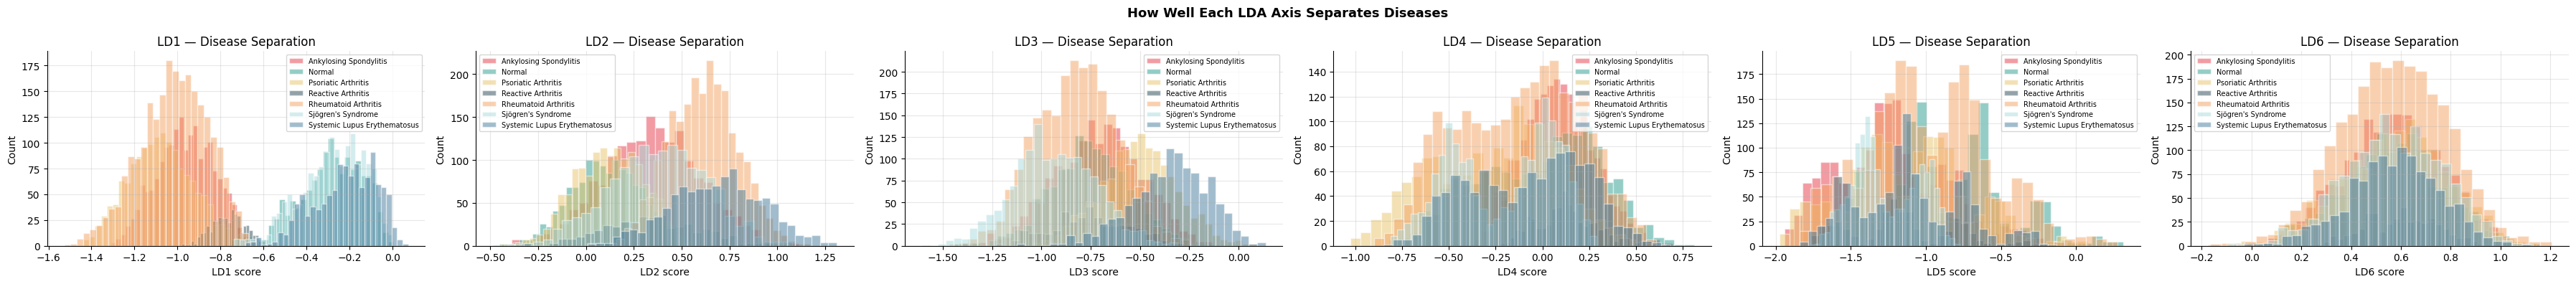

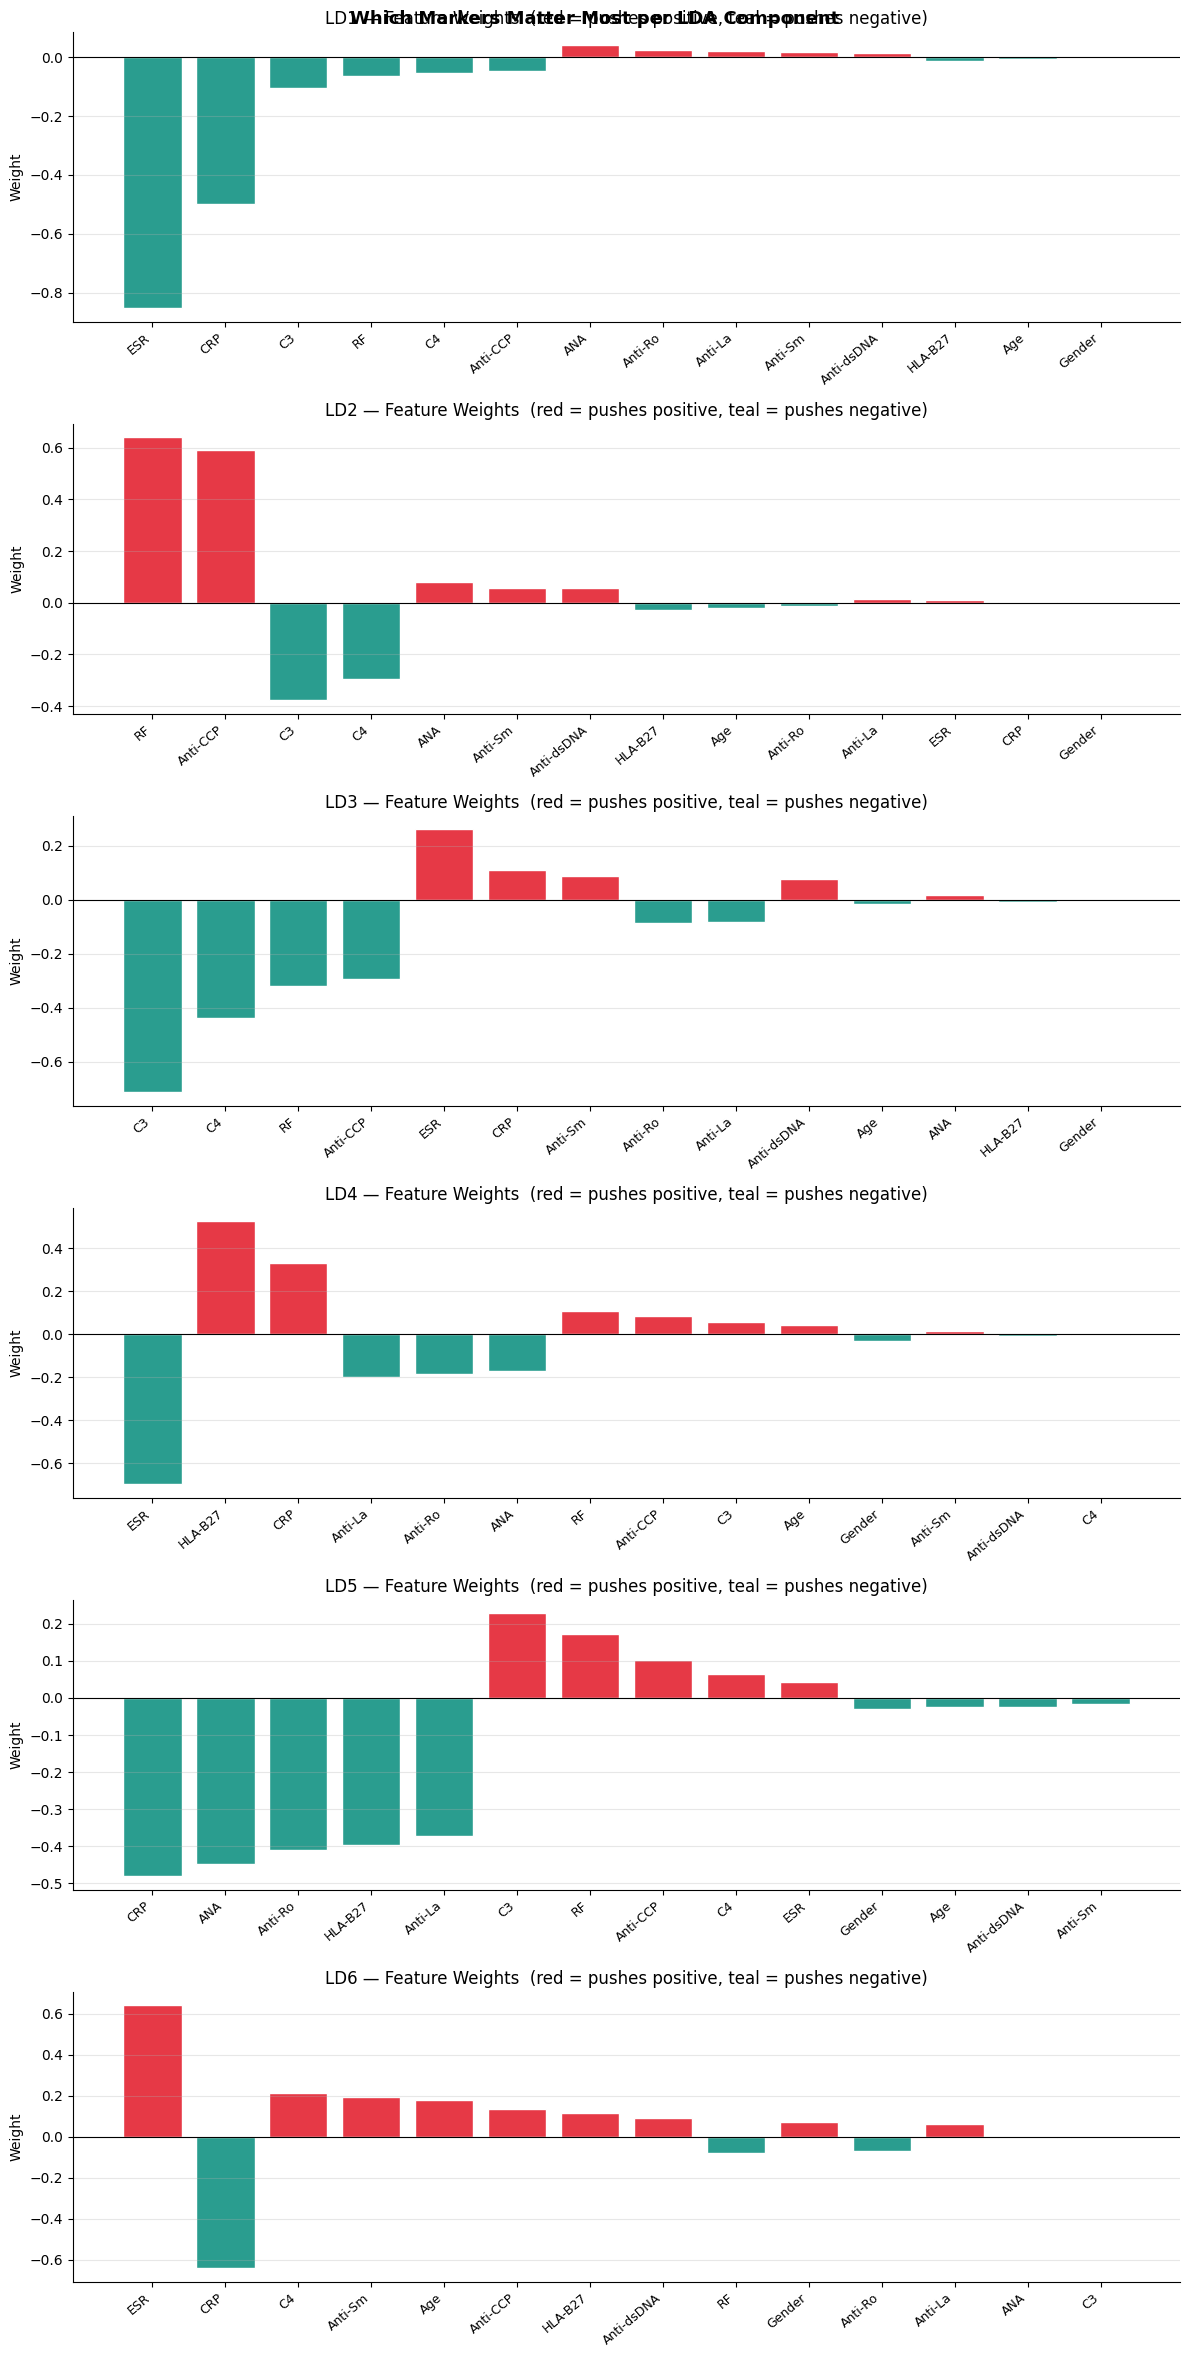

In [15]:
# LDA Projection Scatter
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
COLORS = ['#E63946', '#2A9D8F', '#E9C46A', '#264653',
          '#F4A261', '#A8DADC', '#457B9D', '#1D3557']

# Left — predicted labels
for idx, disease in enumerate(np.unique(y_pred)):
    mask = y_pred == disease
    axes[0].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    c=COLORS[idx], s=25, alpha=0.6, label=disease)
axes[0].set_title('LDA Projection — Predicted Labels')
axes[0].set_xlabel('LD1'), axes[0].set_ylabel('LD2')
axes[0].legend(fontsize=8), axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Right — actual ground truth
for idx, disease in enumerate(np.unique(y)):
    mask = y == disease
    axes[1].scatter(X_lda[mask, 0], X_lda[mask, 1],
                    c=COLORS[idx], s=25, alpha=0.6, label=disease)
axes[1].set_title('LDA Projection — Actual Labels')
axes[1].set_xlabel('LD1'), axes[1].set_ylabel('LD2')
axes[1].legend(fontsize=8), axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('LDA Space — Predicted vs Actual', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# b. Class Separation Per LD Axis
fig, axes = plt.subplots(1, N_COMPONENTS, figsize=(6 * N_COMPONENTS, 4))
if N_COMPONENTS == 1:
    axes = [axes]

for comp in range(N_COMPONENTS):
    for idx, disease in enumerate(np.unique(y)):
        mask   = y == disease
        values = X_lda[mask, comp]
        axes[comp].hist(values, bins=30, alpha=0.5,
                        color=COLORS[idx], label=disease, edgecolor='white')
    axes[comp].set_title(f'LD{comp+1} — Disease Separation')
    axes[comp].set_xlabel(f'LD{comp+1} score')
    axes[comp].set_ylabel('Count')
    axes[comp].legend(fontsize=7)
    axes[comp].grid(alpha=0.3)
    axes[comp].spines[['top', 'right']].set_visible(False)

plt.suptitle('How Well Each LDA Axis Separates Diseases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# c. Feature Importance
feature_names = df.drop('Disease', axis=1).columns.tolist()

fig, axes = plt.subplots(N_COMPONENTS, 1, figsize=(12, 4 * N_COMPONENTS))
if N_COMPONENTS == 1:
    axes = [axes]

for comp in range(N_COMPONENTS):
    weights  = lda_components[:, comp]
    sorted_i = np.argsort(np.abs(weights))[::-1]
    colors   = ['#E63946' if w > 0 else '#2A9D8F' for w in weights[sorted_i]]

    axes[comp].bar(range(len(weights)), weights[sorted_i],
                   color=colors, edgecolor='white')
    axes[comp].set_xticks(range(len(weights)))
    axes[comp].set_xticklabels([feature_names[i] for i in sorted_i],
                                rotation=40, ha='right', fontsize=9)
    axes[comp].set_title(f'LD{comp+1} — Feature Weights  '
                         f'(red = pushes positive, teal = pushes negative)')
    axes[comp].set_ylabel('Weight')
    axes[comp].axhline(0, color='black', linewidth=0.8)
    axes[comp].grid(axis='y', alpha=0.3)
    axes[comp].spines[['top', 'right']].set_visible(False)

plt.suptitle('Which Markers Matter Most per LDA Component',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()